In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/KaggleV2-May-2016.csv')

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 110527
Number of columns: 14


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
print("Gender values:")
print(df['Gender'].unique())

print("\nNo-show values:")
print(df['No-show'].unique())

print("\nScholarship values:")
print(df['Scholarship'].unique())

print("\nSMS received values:")
print(df['SMS_received'].unique())

Gender values:
['F' 'M']

No-show values:
['No' 'Yes']

Scholarship values:
[0 1]

SMS received values:
[0 1]


In [9]:
print(df['Age'].describe())

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64


In [10]:
print("Patients with age below 0:")
print(df[df['Age'] < 0])

print("\nPatients with age above 100:")
print(df[df['Age'] > 100][['Age', 'Gender']].head(20))

Patients with age below 0:
          PatientId  AppointmentID Gender          ScheduledDay  \
99832  4.659432e+14        5775010      F  2016-06-06T08:58:13Z   

             AppointmentDay  Age Neighbourhood  Scholarship  Hipertension  \
99832  2016-06-06T00:00:00Z   -1         ROMÃO            0             0   

       Diabetes  Alcoholism  Handcap  SMS_received No-show  
99832         0           0        0             0      No  

Patients with age above 100:
       Age Gender
58014  102      F
63912  115      F
63915  115      F
68127  115      F
76284  115      F
90372  102      F
97666  115      F


In [11]:
print(df['No-show'].value_counts())

print("\nPercentage distribution:")
print(df['No-show'].value_counts(normalize=True) * 100)

No-show
No     88208
Yes    22319
Name: count, dtype: int64

Percentage distribution:
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


In [12]:
data = df.copy()

print("Working dataset shape:", data.shape)

Working dataset shape: (110527, 14)


In [13]:
data.rename(columns={
    'PatientId': 'Patient_ID',
    'AppointmentID': 'Appointment_ID',
    'ScheduledDay': 'Scheduled_Day',
    'AppointmentDay': 'Appointment_Day',
    'Neighbourhood': 'Neighborhood',
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'No-show': 'No_Show'
}, inplace=True)

print(data.columns.tolist())

['Patient_ID', 'Appointment_ID', 'Gender', 'Scheduled_Day', 'Appointment_Day', 'Age', 'Neighborhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_Show']


In [14]:
data = data.drop_duplicates()

print("Dataset shape after removing duplicates:", data.shape)

Dataset shape after removing duplicates: (110527, 14)


In [15]:
data.loc[data['Age'] < 0, 'Age'] = np.nan

data = data.dropna(subset=['Age'])

print("Dataset shape after handling invalid age:", data.shape)

Dataset shape after handling invalid age: (110526, 14)


In [16]:
data['Scheduled_Day'] = pd.to_datetime(data['Scheduled_Day'])
data['Appointment_Day'] = pd.to_datetime(data['Appointment_Day'])

print(data[['Scheduled_Day', 'Appointment_Day']].dtypes)

Scheduled_Day      datetime64[ns, UTC]
Appointment_Day    datetime64[ns, UTC]
dtype: object


In [17]:
data['Waiting_Days'] = (
    data['Appointment_Day'] - data['Scheduled_Day']
).dt.days

data[['Scheduled_Day', 'Appointment_Day', 'Waiting_Days']].head()

,Scheduled_Day,Appointment_Day,Waiting_Days
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-1
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-1
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-1
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-1
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-1


In [18]:
negative_waiting = data[data['Waiting_Days'] < 0]

print("Number of records with negative waiting days:", len(negative_waiting))

Number of records with negative waiting days: 38567


In [19]:
data[data['Waiting_Days'] < 0][
    ['Scheduled_Day', 'Appointment_Day', 'Waiting_Days']
].head(10)

,Scheduled_Day,Appointment_Day,Waiting_Days
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-1
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-1
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-1
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-1
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-1
8,2016-04-29 08:02:16+00:00,2016-04-29 00:00:00+00:00,-1
19,2016-04-29 10:43:14+00:00,2016-04-29 00:00:00+00:00,-1
24,2016-04-29 14:19:19+00:00,2016-04-29 00:00:00+00:00,-1
26,2016-04-29 14:19:42+00:00,2016-04-29 00:00:00+00:00,-1
28,2016-04-29 15:48:02+00:00,2016-04-29 00:00:00+00:00,-1


In [20]:
data['Scheduled_Date'] = data['Scheduled_Day'].dt.date
data['Appointment_Date'] = data['Appointment_Day'].dt.date

data['Waiting_Days'] = (
    pd.to_datetime(data['Appointment_Date']) -
    pd.to_datetime(data['Scheduled_Date'])
).dt.days

negative_waiting = data[data['Waiting_Days'] < 0]

print("Number of records with negative waiting days:", len(negative_waiting))

Number of records with negative waiting days: 5


In [21]:
data[data['Waiting_Days'] < 0][
    ['Patient_ID', 'Scheduled_Day', 'Appointment_Day', 'Scheduled_Date', 'Appointment_Date', 'Waiting_Days']
]

,Patient_ID,Scheduled_Day,Appointment_Day,Scheduled_Date,Appointment_Date,Waiting_Days
27033,7.839273e+12,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,2016-05-10,2016-05-09,-1
55226,7.896294e+12,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,2016-05-18,2016-05-17,-1
64175,2.425226e+13,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,2016-05-05,2016-05-04,-1
71533,9.982316e+14,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,2016-05-11,2016-05-05,-6
72362,3.787482e+12,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,2016-05-04,2016-05-03,-1


In [22]:
data = data[data['Waiting_Days'] >= 0].copy()

print("Dataset shape after removing invalid waiting periods:", data.shape)

Dataset shape after removing invalid waiting periods: (110521, 17)


In [23]:
print("Remaining negative waiting days:", (data['Waiting_Days'] < 0).sum())

Remaining negative waiting days: 0


In [24]:
data['Appointment_Weekday'] = data['Appointment_Day'].dt.day_name()

data[['Appointment_Day', 'Appointment_Weekday']].head()

,Appointment_Day,Appointment_Weekday
0,2016-04-29 00:00:00+00:00,Friday
1,2016-04-29 00:00:00+00:00,Friday
2,2016-04-29 00:00:00+00:00,Friday
3,2016-04-29 00:00:00+00:00,Friday
4,2016-04-29 00:00:00+00:00,Friday


In [25]:
data['Scheduled_Weekday'] = data['Scheduled_Day'].dt.day_name()

data[['Scheduled_Day', 'Scheduled_Weekday']].head()

,Scheduled_Day,Scheduled_Weekday
0,2016-04-29 18:38:08+00:00,Friday
1,2016-04-29 16:08:27+00:00,Friday
2,2016-04-29 16:19:04+00:00,Friday
3,2016-04-29 17:29:31+00:00,Friday
4,2016-04-29 16:07:23+00:00,Friday


In [26]:
data['Appointment_Month'] = data['Appointment_Day'].dt.month_name()

data[['Appointment_Day', 'Appointment_Month']].head()

,Appointment_Day,Appointment_Month
0,2016-04-29 00:00:00+00:00,April
1,2016-04-29 00:00:00+00:00,April
2,2016-04-29 00:00:00+00:00,April
3,2016-04-29 00:00:00+00:00,April
4,2016-04-29 00:00:00+00:00,April


In [27]:
data['Appointment_Day_Number'] = data['Appointment_Day'].dt.day

data[['Appointment_Day', 'Appointment_Day_Number']].head()

,Appointment_Day,Appointment_Day_Number
0,2016-04-29 00:00:00+00:00,29
1,2016-04-29 00:00:00+00:00,29
2,2016-04-29 00:00:00+00:00,29
3,2016-04-29 00:00:00+00:00,29
4,2016-04-29 00:00:00+00:00,29


In [28]:
data['Appointment_Year'] = data['Appointment_Day'].dt.year

data[['Appointment_Day', 'Appointment_Year']].head()

,Appointment_Day,Appointment_Year
0,2016-04-29 00:00:00+00:00,2016
1,2016-04-29 00:00:00+00:00,2016
2,2016-04-29 00:00:00+00:00,2016
3,2016-04-29 00:00:00+00:00,2016
4,2016-04-29 00:00:00+00:00,2016


In [29]:
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif age <= 19:
        return 'Teenager'
    elif age <= 39:
        return 'Young Adult'
    elif age <= 59:
        return 'Middle-Aged Adult'
    elif age <= 79:
        return 'Senior'
    else:
        return 'Elderly'

data['Age_Group'] = data['Age'].apply(categorize_age)

print(data['Age_Group'].value_counts())

Age_Group
Middle-Aged Adult    30072
Young Adult          28868
Child                21035
Senior               17810
Teenager              9374
Elderly               3362
Name: count, dtype: int64


In [30]:
age_group_noshow = pd.crosstab(
    data['Age_Group'],
    data['No_Show'],
    normalize='index'
) * 100

age_group_noshow = age_group_noshow.round(2)

print(age_group_noshow)

No_Show               No    Yes
Age_Group                      
Child              79.53  20.47
Elderly            83.67  16.33
Middle-Aged Adult  81.19  18.81
Senior             84.88  15.12
Teenager           74.05  25.95
Young Adult        76.87  23.13


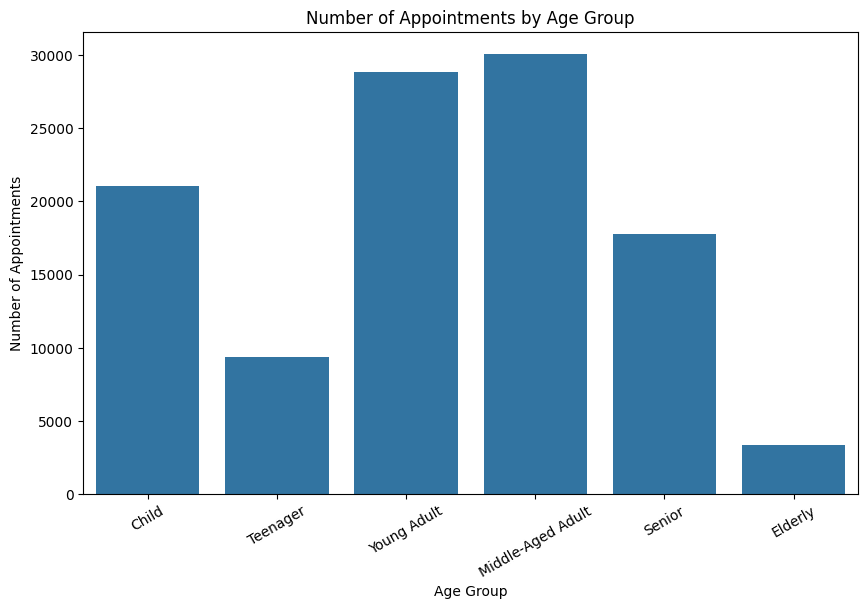

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=data,
    x='Age_Group',
    order=[
        'Child',
        'Teenager',
        'Young Adult',
        'Middle-Aged Adult',
        'Senior',
        'Elderly'
    ]
)

plt.title('Number of Appointments by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=30)
plt.show()

In [32]:
data['No_Show_Flag'] = data['No_Show'].map({
    'No': 0,
    'Yes': 1
})

print(data[['No_Show', 'No_Show_Flag']].head(10))

  No_Show  No_Show_Flag
0      No             0
1      No             0
2      No             0
3      No             0
4      No             0
5      No             0
6     Yes             1
7     Yes             1
8      No             0
9      No             0


In [33]:
print("Target variable distribution:")
print(data['No_Show_Flag'].value_counts())

print("\nMissing values in target variable:")
print(data['No_Show_Flag'].isnull().sum())

Target variable distribution:
No_Show_Flag
0    88207
1    22314
Name: count, dtype: int64

Missing values in target variable:
0


In [34]:
print("Current dataset shape:", data.shape)

print("\nCurrent columns:")
print(data.columns.tolist())

Current dataset shape: (110521, 24)

Current columns:
['Patient_ID', 'Appointment_ID', 'Gender', 'Scheduled_Day', 'Appointment_Day', 'Age', 'Neighborhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_Show', 'Waiting_Days', 'Scheduled_Date', 'Appointment_Date', 'Appointment_Weekday', 'Scheduled_Weekday', 'Appointment_Month', 'Appointment_Day_Number', 'Appointment_Year', 'Age_Group', 'No_Show_Flag']


In [35]:
appointment_status = data['No_Show'].value_counts()

print("Appointment Status:")
print(appointment_status)

Appointment Status:
No_Show
No     88207
Yes    22314
Name: count, dtype: int64


In [36]:
appointment_percentage = (
    data['No_Show']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Appointment Status Percentage:")
print(appointment_percentage)

Appointment Status Percentage:
No_Show
No     79.81
Yes    20.19
Name: proportion, dtype: float64


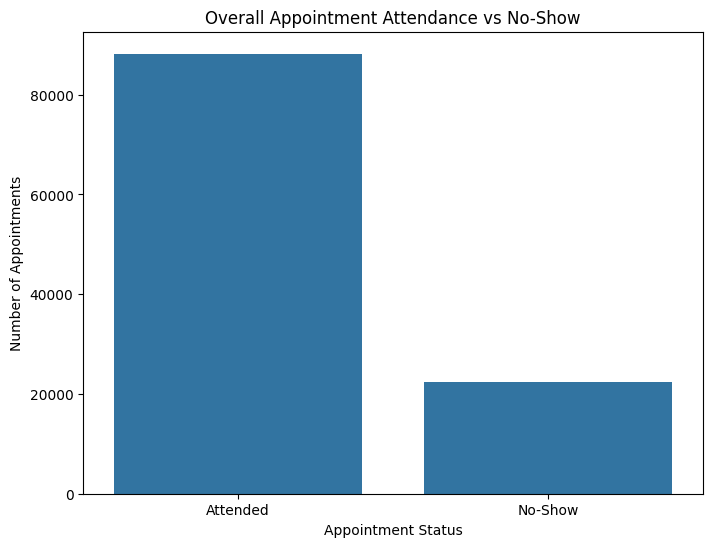

In [37]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x='No_Show',
    order=['No', 'Yes']
)

plt.title('Overall Appointment Attendance vs No-Show')
plt.xlabel('Appointment Status')
plt.ylabel('Number of Appointments')

plt.xticks(
    [0, 1],
    ['Attended', 'No-Show']
)

plt.show()

In [38]:
gender_counts = data['Gender'].value_counts()

print("Appointments by Gender:")
print(gender_counts)

Appointments by Gender:
Gender
F    71836
M    38685
Name: count, dtype: int64


In [39]:
gender_noshow_rate = (
    data.groupby('Gender')['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
)

print("No-Show Rate by Gender (%):")
print(gender_noshow_rate)

No-Show Rate by Gender (%):
Gender
F    20.31
M    19.96
Name: No_Show_Flag, dtype: float64


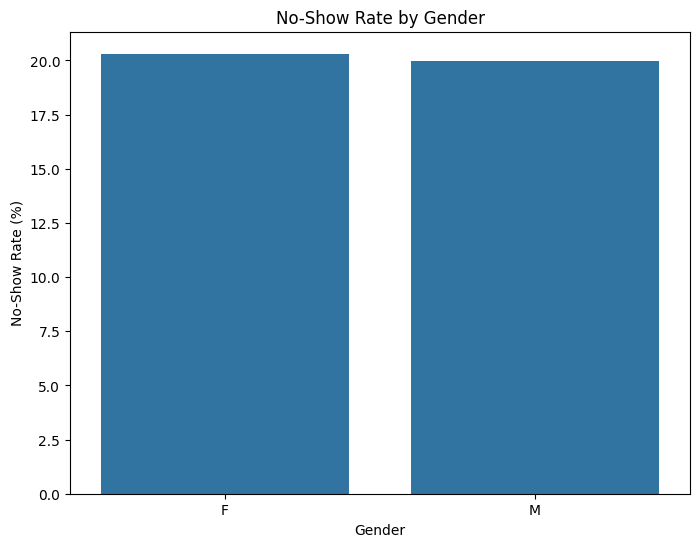

In [40]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_noshow_rate.index,
    y=gender_noshow_rate.values
)

plt.title('No-Show Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('No-Show Rate (%)')

plt.show()

In [41]:
gender_summary = pd.DataFrame({
    'Appointment_Count': data['Gender'].value_counts(),
    'No_Show_Rate (%)': gender_noshow_rate
})

print(gender_summary)

        Appointment_Count  No_Show_Rate (%)
Gender                                     
F                   71836             20.31
M                   38685             19.96


In [42]:
age_noshow_rate = (
    data.groupby('Age_Group')['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
)

age_order = [
    'Child',
    'Teenager',
    'Young Adult',
    'Middle-Aged Adult',
    'Senior',
    'Elderly'
]

age_noshow_rate = age_noshow_rate.reindex(age_order)

print("No-Show Rate by Age Group (%):")
print(age_noshow_rate)

No-Show Rate by Age Group (%):
Age_Group
Child                20.47
Teenager             25.95
Young Adult          23.13
Middle-Aged Adult    18.81
Senior               15.12
Elderly              16.33
Name: No_Show_Flag, dtype: float64


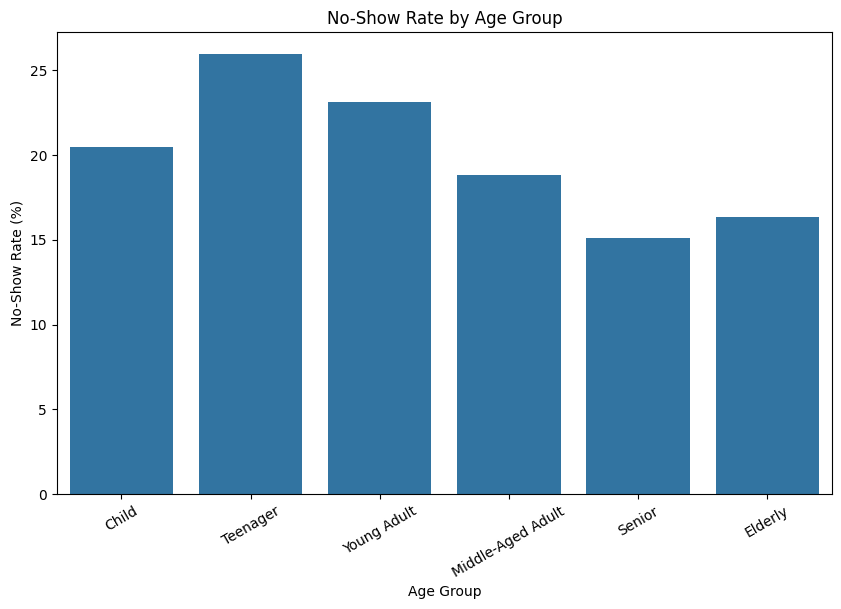

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_noshow_rate.index,
    y=age_noshow_rate.values
)

plt.title('No-Show Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=30)

plt.show()

In [44]:
age_rate = (
    data.groupby('Age')['No_Show_Flag']
    .mean()
    .mul(100)
)

print("Top 15 ages with highest no-show rates:")
print(age_rate.sort_values(ascending=False).head(15).round(2))

Top 15 ages with highest no-show rates:
Age
115.0    60.00
14.0     28.26
13.0     27.47
15.0     26.59
9.0      26.53
25.0     26.43
17.0     26.24
24.0     25.85
22.0     25.45
19.0     25.45
23.0     25.43
16.0     25.18
95.0     25.00
12.0     24.91
20.0     24.70
Name: No_Show_Flag, dtype: float64


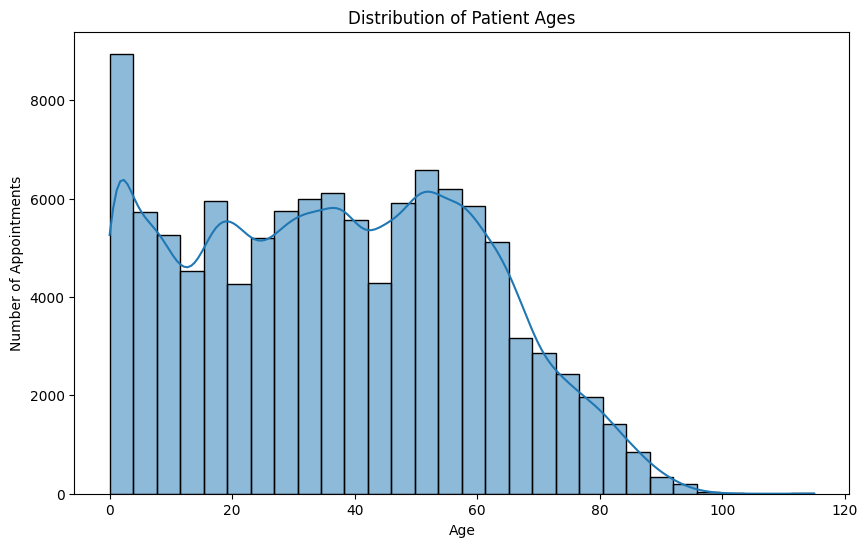

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x='Age',
    bins=30,
    kde=True
)

plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Number of Appointments')

plt.show()

In [46]:
print("Waiting Days Statistics:")
print(data['Waiting_Days'].describe())

Waiting Days Statistics:
count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Waiting_Days, dtype: float64


In [47]:
def categorize_waiting_days(days):
    if days == 0:
        return 'Same Day'
    elif days <= 7:
        return '1 Week'
    elif days <= 30:
        return '1 Month'
    elif days <= 90:
        return '1-3 Months'
    else:
        return '3+ Months'

data['Waiting_Time_Group'] = data['Waiting_Days'].apply(categorize_waiting_days)

print(data['Waiting_Time_Group'].value_counts())

Waiting_Time_Group
Same Day      38562
1 Week        32185
1 Month       29396
1-3 Months    10161
3+ Months       217
Name: count, dtype: int64


In [48]:
waiting_noshow_rate = (
    data.groupby('Waiting_Time_Group')['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
)

waiting_order = [
    'Same Day',
    '1 Week',
    '1 Month',
    '1-3 Months',
    '3+ Months'
]

waiting_noshow_rate = waiting_noshow_rate.reindex(waiting_order)

print("No-Show Rate by Waiting Time (%):")
print(waiting_noshow_rate)

No-Show Rate by Waiting Time (%):
Waiting_Time_Group
Same Day       4.65
1 Week        24.15
1 Month       31.72
1-3 Months    33.16
3+ Months     25.81
Name: No_Show_Flag, dtype: float64


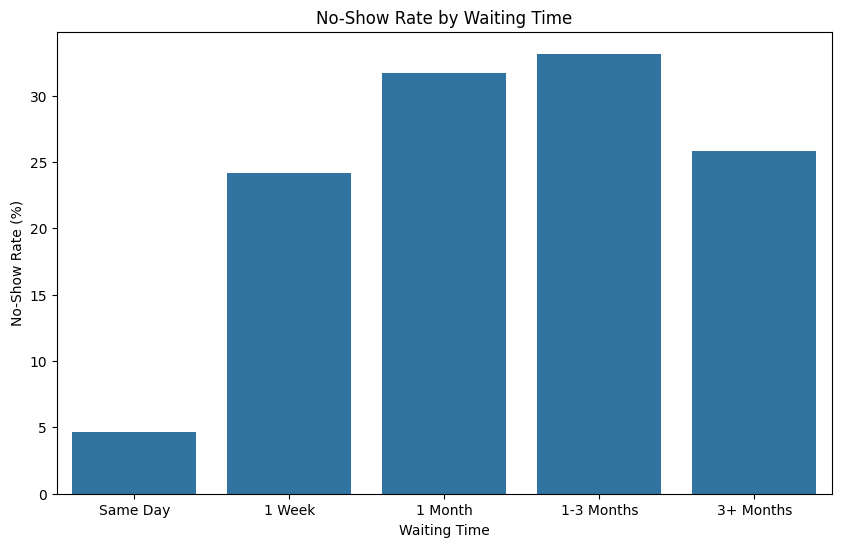

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=waiting_noshow_rate.index,
    y=waiting_noshow_rate.values
)

plt.title('No-Show Rate by Waiting Time')
plt.xlabel('Waiting Time')
plt.ylabel('No-Show Rate (%)')

plt.show()

In [50]:
waiting_crosstab = pd.crosstab(
    data['Waiting_Time_Group'],
    data['No_Show'],
    normalize='index'
) * 100

waiting_crosstab = waiting_crosstab.reindex(waiting_order)

print("Appointment Outcome (%) by Waiting Time:")
print(waiting_crosstab.round(2))

Appointment Outcome (%) by Waiting Time:
No_Show                No    Yes
Waiting_Time_Group              
Same Day            95.35   4.65
1 Week              75.85  24.15
1 Month             68.28  31.72
1-3 Months          66.84  33.16
3+ Months           74.19  25.81


In [51]:
sms_counts = data['SMS_received'].value_counts()

print("SMS Reminder Distribution:")
print(sms_counts)

SMS Reminder Distribution:
SMS_received
0    75039
1    35482
Name: count, dtype: int64


In [52]:
sms_noshow_rate = (
    data.groupby('SMS_received')['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
)

sms_noshow_rate.index = [
    'No SMS' if x == 0 else 'SMS Received'
    for x in sms_noshow_rate.index
]

print("No-Show Rate by SMS Reminder:")
print(sms_noshow_rate)

No-Show Rate by SMS Reminder:
No SMS          16.70
SMS Received    27.57
Name: No_Show_Flag, dtype: float64


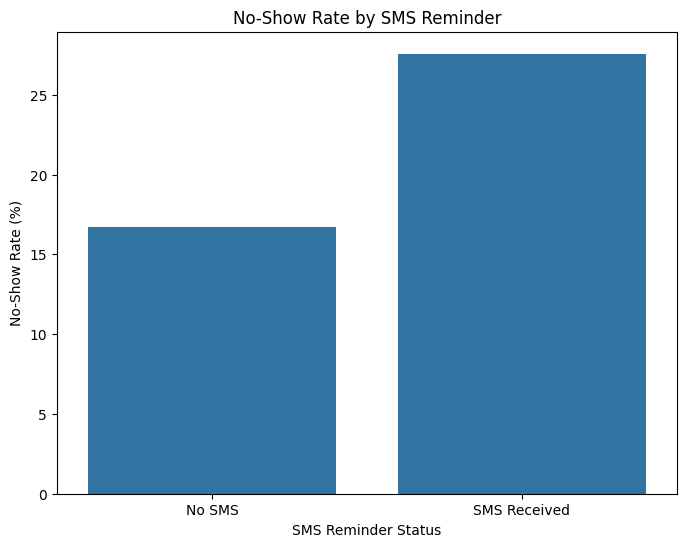

In [53]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=sms_noshow_rate.index,
    y=sms_noshow_rate.values
)

plt.title('No-Show Rate by SMS Reminder')
plt.xlabel('SMS Reminder Status')
plt.ylabel('No-Show Rate (%)')

plt.show()

In [54]:
sms_waiting_analysis = (
    data.groupby(['Waiting_Time_Group', 'SMS_received'])['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

sms_waiting_analysis['SMS_received'] = sms_waiting_analysis['SMS_received'].map({
    0: 'No SMS',
    1: 'SMS Received'
})

sms_waiting_analysis['Waiting_Time_Group'] = pd.Categorical(
    sms_waiting_analysis['Waiting_Time_Group'],
    categories=waiting_order,
    ordered=True
)

sms_waiting_analysis = sms_waiting_analysis.sort_values(
    'Waiting_Time_Group'
)

print(sms_waiting_analysis)

  Waiting_Time_Group  SMS_received  No_Show_Flag
8           Same Day        No SMS          4.65
2             1 Week        No SMS         24.36
3             1 Week  SMS Received         23.76
0            1 Month        No SMS         35.55
1            1 Month  SMS Received         29.13
4         1-3 Months        No SMS         37.79
5         1-3 Months  SMS Received         30.28
6          3+ Months        No SMS         24.36
7          3+ Months  SMS Received         26.62


In [55]:
health_conditions = {
    'Hypertension': 'Hypertension',
    'Diabetes': 'Diabetes',
    'Alcoholism': 'Alcoholism',
    'Handicap': 'Handicap'
}

print("Health condition columns:")
for condition in health_conditions:
    print("-", condition)

Health condition columns:
- Hypertension
- Diabetes
- Alcoholism
- Handicap


In [56]:
health_results = []

for condition in health_conditions.values():
    no_condition_rate = (
        data.loc[data[condition] == 0, 'No_Show_Flag'].mean() * 100
    )

    condition_rate = (
        data.loc[data[condition] == 1, 'No_Show_Flag'].mean() * 100
    )

    health_results.append({
        'Health_Condition': condition,
        'Without_Condition_No_Show_Rate': round(no_condition_rate, 2),
        'With_Condition_No_Show_Rate': round(condition_rate, 2)
    })

health_summary = pd.DataFrame(health_results)

print(health_summary)

  Health_Condition  Without_Condition_No_Show_Rate  \
0     Hypertension                           20.90   
1         Diabetes                           20.36   
2       Alcoholism                           20.19   
3         Handicap                           20.23   

   With_Condition_No_Show_Rate  
0                        17.30  
1                        18.00  
2                        20.15  
3                        17.84  


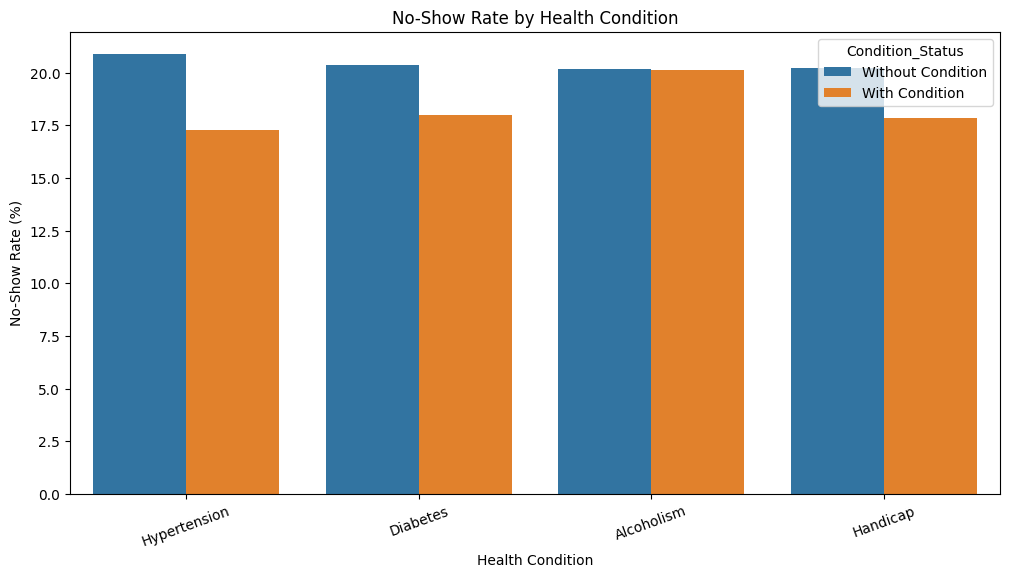

In [57]:
health_plot_data = health_summary.melt(
    id_vars='Health_Condition',
    var_name='Condition_Status',
    value_name='No_Show_Rate'
)

health_plot_data['Condition_Status'] = health_plot_data[
    'Condition_Status'
].replace({
    'Without_Condition_No_Show_Rate': 'Without Condition',
    'With_Condition_No_Show_Rate': 'With Condition'
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=health_plot_data,
    x='Health_Condition',
    y='No_Show_Rate',
    hue='Condition_Status'
)

plt.title('No-Show Rate by Health Condition')
plt.xlabel('Health Condition')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=20)

plt.show()

In [58]:
weekday_noshow_rate = (
    data.groupby('Appointment_Weekday')['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
)

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_noshow_rate = weekday_noshow_rate.reindex(weekday_order)

print("No-Show Rate by Appointment Weekday (%):")
print(weekday_noshow_rate)

No-Show Rate by Appointment Weekday (%):
Appointment_Weekday
Monday       20.64
Tuesday      20.09
Wednesday    19.69
Thursday     19.35
Friday       21.23
Saturday     23.08
Sunday         NaN
Name: No_Show_Flag, dtype: float64


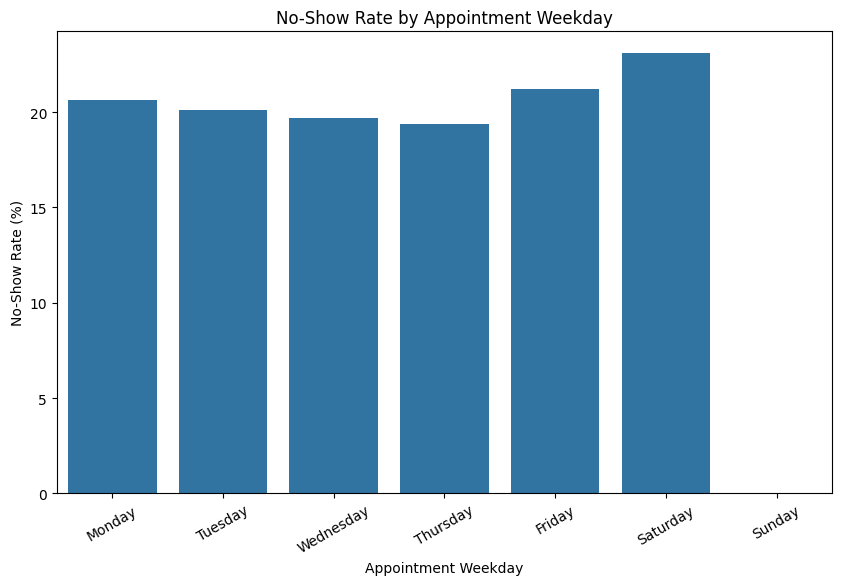

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=weekday_noshow_rate.index,
    y=weekday_noshow_rate.values
)

plt.title('No-Show Rate by Appointment Weekday')
plt.xlabel('Appointment Weekday')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=30)

plt.show()

In [60]:
month_noshow_rate = (
    data.groupby('Appointment_Month')['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
)

month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

month_noshow_rate = month_noshow_rate.reindex(month_order)

print("No-Show Rate by Appointment Month (%):")
print(month_noshow_rate)

No-Show Rate by Appointment Month (%):
Appointment_Month
January        NaN
February       NaN
March          NaN
April        19.57
May          20.78
June         18.46
July           NaN
August         NaN
September      NaN
October        NaN
November       NaN
December       NaN
Name: No_Show_Flag, dtype: float64


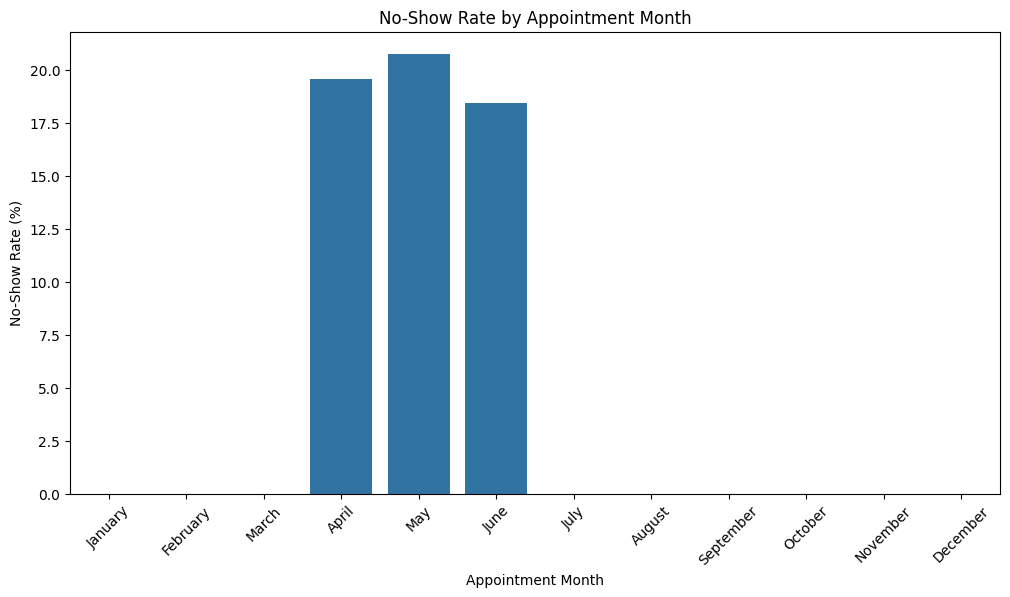

In [61]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=month_noshow_rate.index,
    y=month_noshow_rate.values
)

plt.title('No-Show Rate by Appointment Month')
plt.xlabel('Appointment Month')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [62]:
neighborhood_noshow_rate = (
    data.groupby('Neighborhood')['No_Show_Flag']
    .agg(['mean', 'count'])
)

neighborhood_noshow_rate['No_Show_Rate (%)'] = (
    neighborhood_noshow_rate['mean'] * 100
).round(2)

neighborhood_noshow_rate.rename(
    columns={'count': 'Appointment_Count'},
    inplace=True
)

neighborhood_noshow_rate.drop(
    columns='mean',
    inplace=True
)

neighborhood_noshow_rate = neighborhood_noshow_rate.sort_values(
    'No_Show_Rate (%)',
    ascending=False
)

print("Top 15 Neighborhoods by No-Show Rate:")
print(neighborhood_noshow_rate.head(15))

Top 15 Neighborhoods by No-Show Rate:
                             Appointment_Count  No_Show_Rate (%)
Neighborhood                                                    
ILHAS OCEÂNICAS DE TRINDADE                  2            100.00
SANTOS DUMONT                             1276             28.92
SANTA CECÍLIA                              448             27.46
SANTA CLARA                                506             26.48
ITARARÉ                                   3514             26.27
JESUS DE NAZARETH                         2853             24.40
HORTO                                      175             24.00
ILHA DO PRÍNCIPE                          2266             23.48
CARATOÍRA                                 2565             23.04
ANDORINHAS                                2262             23.03
PRAIA DO SUÁ                              1288             22.83
GURIGICA                                  2018             22.60
BENTO FERREIRA                             858      

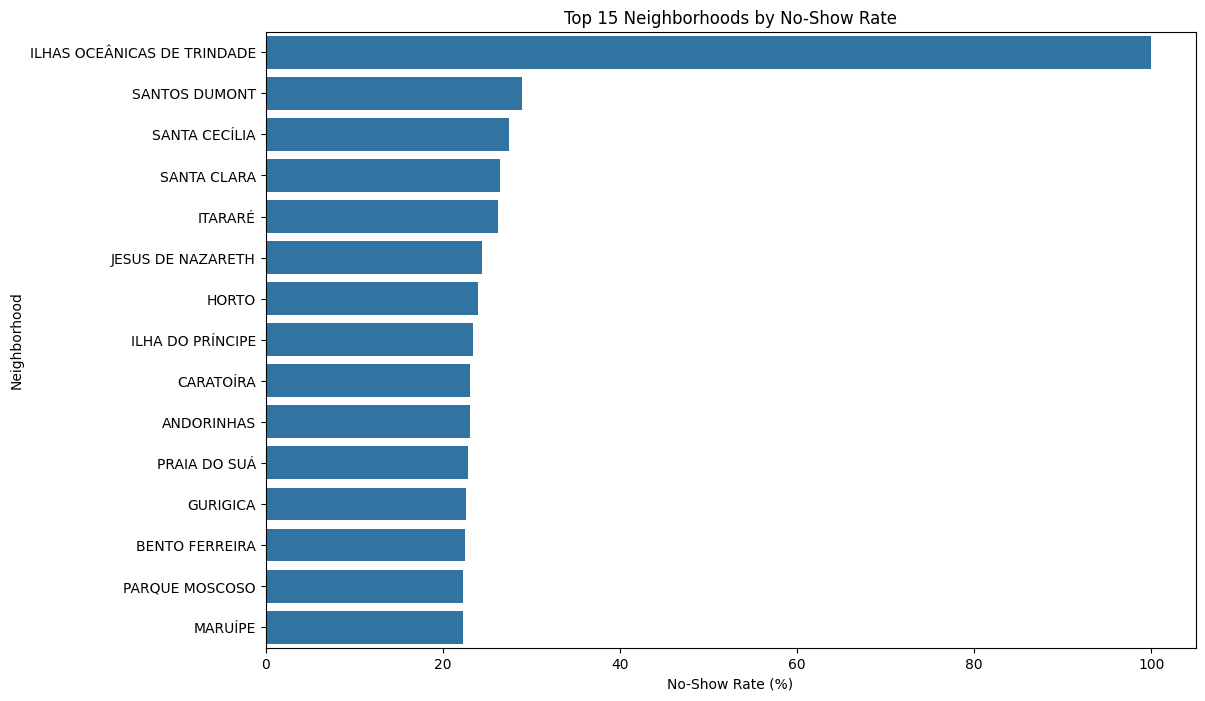

In [63]:
top_neighborhoods = neighborhood_noshow_rate.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_neighborhoods.reset_index(),
    x='No_Show_Rate (%)',
    y='Neighborhood'
)

plt.title('Top 15 Neighborhoods by No-Show Rate')
plt.xlabel('No-Show Rate (%)')
plt.ylabel('Neighborhood')

plt.show()

In [64]:
top_volume_neighborhoods = (
    data['Neighborhood']
    .value_counts()
    .head(15)
)

print("Top 15 Neighborhoods by Appointment Volume:")
print(top_volume_neighborhoods)

Top 15 Neighborhoods by Appointment Volume:
Neighborhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4430
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
SANTA MARTHA         3131
TABUAZEIRO           3131
JESUS DE NAZARETH    2853
BONFIM               2773
SANTO ANTÔNIO        2744
SANTO ANDRÉ          2571
CARATOÍRA            2565
JABOUR               2509
SÃO PEDRO            2448
Name: count, dtype: int64


In [65]:
reliable_neighborhoods = neighborhood_noshow_rate[
    neighborhood_noshow_rate['Appointment_Count'] >= 500
].sort_values(
    'No_Show_Rate (%)',
    ascending=False
)

print("Neighborhoods with at least 500 appointments:")
print(reliable_neighborhoods)

Neighborhoods with at least 500 appointments:
                     Appointment_Count  No_Show_Rate (%)
Neighborhood                                            
SANTOS DUMONT                     1276             28.92
SANTA CLARA                        506             26.48
ITARARÉ                           3514             26.27
JESUS DE NAZARETH                 2853             24.40
ILHA DO PRÍNCIPE                  2266             23.48
CARATOÍRA                         2565             23.04
ANDORINHAS                        2262             23.03
PRAIA DO SUÁ                      1288             22.83
GURIGICA                          2018             22.60
BENTO FERREIRA                     858             22.49
PARQUE MOSCOSO                     802             22.32
MARUÍPE                           1902             22.29
ILHA DAS CAIEIRAS                 1071             21.94
FONTE GRANDE                       682             21.85
CRUZAMENTO                        1398    

In [66]:
eda_summary = pd.DataFrame({
    'Factor': [
        'Gender',
        'Waiting Time',
        'SMS Reminder',
        'Hypertension',
        'Diabetes',
        'Alcoholism',
        'Handicap',
        'Appointment Weekday',
        'Appointment Month',
        'Neighborhood'
    ],

    'Key_Observation': [
        'Male and female no-show rates are very similar.',
        'No-show rates increase substantially for longer waiting periods, peaking at 1-3 months.',
        'SMS recipients have higher overall no-show rates, but SMS is associated with lower no-show rates for 1 month and 1-3 month waiting groups.',
        'Patients with hypertension have a lower observed no-show rate than those without hypertension.',
        'Patients with diabetes have a lower observed no-show rate than those without diabetes.',
        'Alcoholism shows almost no difference in observed no-show rates.',
        'Patients with handicap have a lower observed no-show rate than those without handicap.',
        'Saturday has the highest observed no-show rate among appointment weekdays.',
        'May has the highest observed no-show rate among the available months.',
        'No-show rates vary considerably across neighborhoods.'
    ]
})

print("Key EDA Findings:")
display(eda_summary)

Key EDA Findings:


,Factor,Key_Observation
0,Gender,Male and female no-show rates are very similar.
1,Waiting Time,No-show rates increase substantially for longe...
2,SMS Reminder,SMS recipients have higher overall no-show rat...
3,Hypertension,Patients with hypertension have a lower observ...
4,Diabetes,Patients with diabetes have a lower observed n...
5,Alcoholism,Alcoholism shows almost no difference in obser...
6,Handicap,Patients with handicap have a lower observed n...
7,Appointment Weekday,Saturday has the highest observed no-show rate...
8,Appointment Month,May has the highest observed no-show rate amon...
9,Neighborhood,No-show rates vary considerably across neighbo...


In [67]:
potential_features = [
    'Waiting_Days',
    'Waiting_Time_Group',
    'SMS_received',
    'Age',
    'Age_Group',
    'Neighborhood',
    'Appointment_Weekday',
    'Appointment_Month',
    'Gender',
    'Hypertension',
    'Diabetes',
    'Alcoholism',
    'Handicap',
    'Scholarship'
]

print("Potential features for machine learning:")
for i, feature in enumerate(potential_features, start=1):
    print(f"{i}. {feature}")

Potential features for machine learning:
1. Waiting_Days
2. Waiting_Time_Group
3. SMS_received
4. Age
5. Age_Group
6. Neighborhood
7. Appointment_Weekday
8. Appointment_Month
9. Gender
10. Hypertension
11. Diabetes
12. Alcoholism
13. Handicap
14. Scholarship


In [68]:
numeric_features = [
    'Age',
    'Scholarship',
    'Hypertension',
    'Diabetes',
    'Alcoholism',
    'Handicap',
    'SMS_received',
    'Waiting_Days',
    'Appointment_Day_Number',
    'Appointment_Year',
    'No_Show_Flag'
]

correlation_matrix = data[numeric_features].corr()

target_correlation = (
    correlation_matrix['No_Show_Flag']
    .sort_values(ascending=False)
)

print("Correlation of Numerical Features with No-Show:")
print(target_correlation)

Correlation of Numerical Features with No-Show:
No_Show_Flag              1.000000
Waiting_Days              0.186320
SMS_received              0.126502
Scholarship               0.029166
Appointment_Day_Number    0.003808
Alcoholism               -0.000181
Handicap                 -0.006290
Diabetes                 -0.015158
Hypertension             -0.035662
Age                      -0.060320
Appointment_Year               NaN
Name: No_Show_Flag, dtype: float64


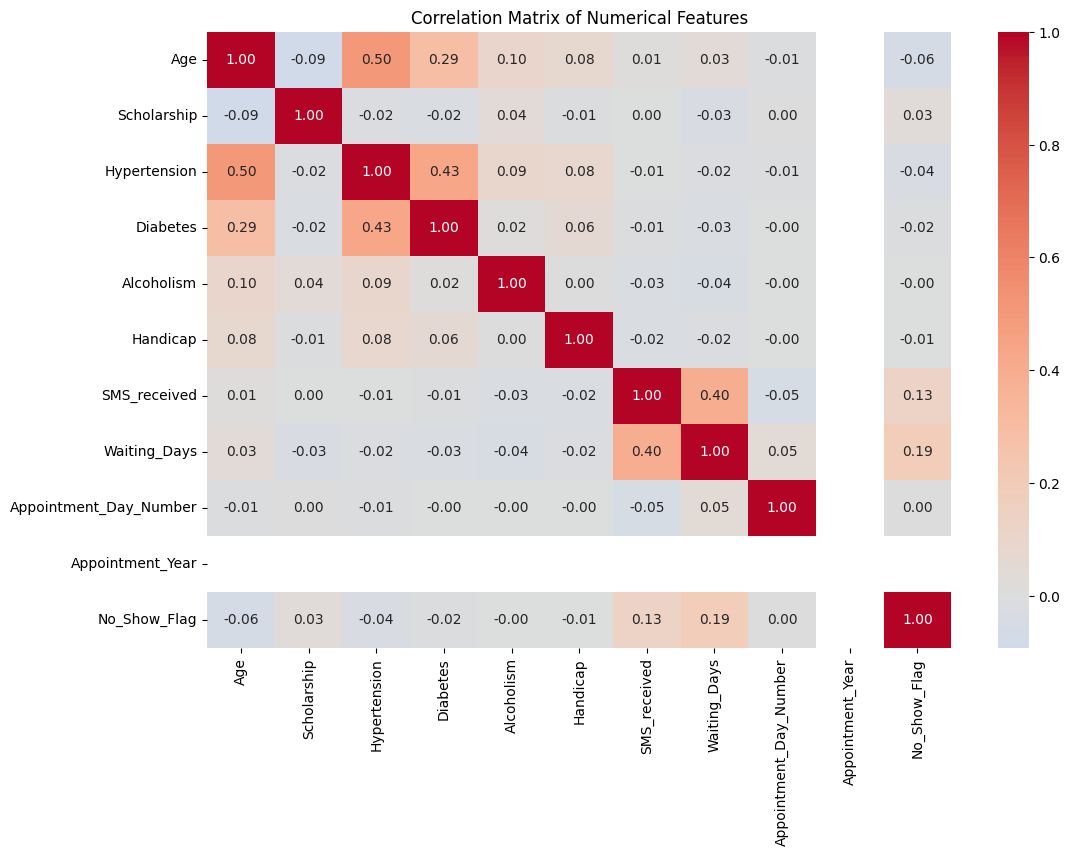

In [69]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

In [70]:
interaction_analysis = (
    data.groupby(['Waiting_Time_Group', 'SMS_received'])['No_Show_Flag']
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

interaction_analysis.columns = ['No SMS', 'SMS Received']

interaction_analysis = interaction_analysis.reindex(waiting_order)

print("Waiting Time + SMS Interaction Analysis:")
print(interaction_analysis)

Waiting Time + SMS Interaction Analysis:
                    No SMS  SMS Received
Waiting_Time_Group                      
Same Day              4.65           NaN
1 Week               24.36         23.76
1 Month              35.55         29.13
1-3 Months           37.79         30.28
3+ Months            24.36         26.62


In [71]:
interaction_analysis['SMS Difference (%)'] = (
    interaction_analysis['SMS Received'] -
    interaction_analysis['No SMS']
).round(2)

print("Effect of SMS within Each Waiting Time Group:")
print(interaction_analysis)

Effect of SMS within Each Waiting Time Group:
                    No SMS  SMS Received  SMS Difference (%)
Waiting_Time_Group                                          
Same Day              4.65           NaN                 NaN
1 Week               24.36         23.76               -0.60
1 Month              35.55         29.13               -6.42
1-3 Months           37.79         30.28               -7.51
3+ Months            24.36         26.62                2.26


In [72]:
from scipy.stats import chi2_contingency

sms_contingency = pd.crosstab(
    data['SMS_received'],
    data['No_Show_Flag']
)

print("Contingency Table:")
print(sms_contingency)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    sms_contingency
)

print("\nChi-Square Test Results:")
print("Chi-Square Statistic:", round(chi2, 4))
print("P-value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

Contingency Table:
No_Show_Flag      0      1
SMS_received              
0             62509  12530
1             25698   9784

Chi-Square Test Results:
Chi-Square Statistic: 1767.9782
P-value: 0.0
Degrees of Freedom: 1


In [73]:
waiting_contingency = pd.crosstab(
    data['Waiting_Time_Group'],
    data['No_Show_Flag']
)

print("Waiting Time Contingency Table:")
print(waiting_contingency)

chi2_waiting, p_value_waiting, dof_waiting, expected_waiting = (
    chi2_contingency(waiting_contingency)
)

print("\nChi-Square Test Results:")
print("Chi-Square Statistic:", round(chi2_waiting, 4))
print("P-value:", p_value_waiting)
print("Degrees of Freedom:", dof_waiting)

Waiting Time Contingency Table:
No_Show_Flag            0     1
Waiting_Time_Group             
1 Month             20071  9325
1 Week              24413  7772
1-3 Months           6792  3369
3+ Months             161    56
Same Day            36770  1792

Chi-Square Test Results:
Chi-Square Statistic: 9584.8094
P-value: 0.0
Degrees of Freedom: 4


In [74]:
data['Waiting_SMS_Group'] = (
    data['Waiting_Time_Group'].astype(str)
    + ' - '
    + data['SMS_received'].map({
        0: 'No SMS',
        1: 'SMS'
    })
)

interaction_contingency = pd.crosstab(
    data['Waiting_SMS_Group'],
    data['No_Show_Flag']
)

chi2_interaction, p_value_interaction, dof_interaction, expected_interaction = (
    chi2_contingency(interaction_contingency)
)

print("Waiting Time + SMS Interaction Chi-Square Test:")
print("Chi-Square Statistic:", round(chi2_interaction, 4))
print("P-value:", p_value_interaction)
print("Degrees of Freedom:", dof_interaction)

Waiting Time + SMS Interaction Chi-Square Test:
Chi-Square Statistic: 9852.1047
P-value: 0.0
Degrees of Freedom: 8


In [75]:
print("Current dataset columns:")
for i, column in enumerate(data.columns, start=1):
    print(f"{i}. {column}")

Current dataset columns:
1. Patient_ID
2. Appointment_ID
3. Gender
4. Scheduled_Day
5. Appointment_Day
6. Age
7. Neighborhood
8. Scholarship
9. Hypertension
10. Diabetes
11. Alcoholism
12. Handicap
13. SMS_received
14. No_Show
15. Waiting_Days
16. Scheduled_Date
17. Appointment_Date
18. Appointment_Weekday
19. Scheduled_Weekday
20. Appointment_Month
21. Appointment_Day_Number
22. Appointment_Year
23. Age_Group
24. No_Show_Flag
25. Waiting_Time_Group
26. Waiting_SMS_Group


In [76]:
# Select features for machine learning
ml_features = [
    'Gender',
    'Age',
    'Neighborhood',
    'Scholarship',
    'Hypertension',
    'Diabetes',
    'Alcoholism',
    'Handicap',
    'SMS_received',
    'Waiting_Days',
    'Appointment_Weekday',
    'Scheduled_Weekday',
    'Appointment_Month',
    'Appointment_Day_Number',
    'Age_Group'
]

# Create ML dataset
ml_data = data[ml_features + ['No_Show_Flag']].copy()

# Display ML dataset shape
print("ML dataset shape:", ml_data.shape)

# Display selected columns
print("\nML dataset columns:")
print(ml_data.columns.tolist())

ML dataset shape: (110521, 16)

ML dataset columns:
['Gender', 'Age', 'Neighborhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'Waiting_Days', 'Appointment_Weekday', 'Scheduled_Weekday', 'Appointment_Month', 'Appointment_Day_Number', 'Age_Group', 'No_Show_Flag']


In [77]:
X = ml_data.drop(columns=['No_Show_Flag'])
y = ml_data['No_Show_Flag']

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature dataset shape: (110521, 15)
Target dataset shape: (110521,)

Target distribution:
No_Show_Flag
0    88207
1    22314
Name: count, dtype: int64


In [78]:
categorical_features = [
    'Gender',
    'Neighborhood',
    'Appointment_Weekday',
    'Scheduled_Weekday',
    'Appointment_Month',
    'Age_Group'
]

numerical_features = [
    'Age',
    'Scholarship',
    'Hypertension',
    'Diabetes',
    'Alcoholism',
    'Handicap',
    'SMS_received',
    'Waiting_Days',
    'Appointment_Day_Number'
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Gender', 'Neighborhood', 'Appointment_Weekday', 'Scheduled_Weekday', 'Appointment_Month', 'Age_Group']

Numerical Features:
['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'Waiting_Days', 'Appointment_Day_Number']


In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [80]:
X_encoded = preprocessor.fit_transform(X)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

Original feature shape: (110521, 15)
Encoded feature shape: (110521, 113)


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training feature shape: (88416, 15)
Testing feature shape: (22105, 15)

Training target distribution:
No_Show_Flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

Testing target distribution:
No_Show_Flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64


In [82]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (88416, 113)
Processed testing data shape: (22105, 113)


In [83]:
print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [84]:
print("===== FINAL ML DATASET CHECK =====")

print("\nTraining data shape:")
print(X_train_processed.shape)

print("\nTesting data shape:")
print(X_test_processed.shape)

print("\nTraining target shape:")
print(y_train.shape)

print("\nTesting target shape:")
print(y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nMissing values in training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in testing data:",
      np.isnan(X_test_processed).sum())

===== FINAL ML DATASET CHECK =====

Training data shape:
(88416, 113)

Testing data shape:
(22105, 113)

Training target shape:
(88416,)

Testing target shape:
(22105,)

Training target distribution:
No_Show_Flag
0    70565
1    17851
Name: count, dtype: int64

Testing target distribution:
No_Show_Flag
0    17642
1     4463
Name: count, dtype: int64

Missing values in training data: 0
Missing values in testing data: 0


In [85]:
if (
    X_train_processed.shape[0] == y_train.shape[0]
    and X_test_processed.shape[0] == y_test.shape[0]
    and np.isnan(X_train_processed).sum() == 0
    and np.isnan(X_test_processed).sum() == 0
):
    print("✅ ML dataset is ready for model training!")
else:
    print("⚠️ Please check the dataset before proceeding.")

✅ ML dataset is ready for model training!


In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_predictions = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print("===== BASELINE MODEL =====")
print("Accuracy:", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1 Score:", round(baseline_f1, 4))

===== BASELINE MODEL =====
Accuracy: 0.7981
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [88]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_processed
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1 Score:", round(logistic_f1, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))

===== LOGISTIC REGRESSION =====
Accuracy: 0.6489
Precision: 0.3069
Recall: 0.5873
F1 Score: 0.4032
ROC-AUC: 0.6697


In [89]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=50,
    random_state=42
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

decision_tree_predictions = decision_tree_model.predict(
    X_test_processed
)

decision_tree_probabilities = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

decision_tree_precision = precision_score(
    y_test,
    decision_tree_predictions
)

decision_tree_recall = recall_score(
    y_test,
    decision_tree_predictions
)

decision_tree_f1 = f1_score(
    y_test,
    decision_tree_predictions
)

decision_tree_roc_auc = roc_auc_score(
    y_test,
    decision_tree_probabilities
)

print("===== DECISION TREE =====")
print("Accuracy:", round(decision_tree_accuracy, 4))
print("Precision:", round(decision_tree_precision, 4))
print("Recall:", round(decision_tree_recall, 4))
print("F1 Score:", round(decision_tree_f1, 4))
print("ROC-AUC:", round(decision_tree_roc_auc, 4))

===== DECISION TREE =====
Accuracy: 0.5846
Precision: 0.3004
Recall: 0.7959
F1 Score: 0.4362
ROC-AUC: 0.7143


In [90]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    X_test_processed
)

random_forest_probabilities = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

print("===== RANDOM FOREST =====")
print("Accuracy:", round(random_forest_accuracy, 4))
print("Precision:", round(random_forest_precision, 4))
print("Recall:", round(random_forest_recall, 4))
print("F1 Score:", round(random_forest_f1, 4))
print("ROC-AUC:", round(random_forest_roc_auc, 4))

===== RANDOM FOREST =====
Accuracy: 0.5876
Precision: 0.3049
Recall: 0.8147
F1 Score: 0.4437
ROC-AUC: 0.7226


In [92]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=30,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

gradient_boosting_predictions = gradient_boosting_model.predict(
    X_test_processed
)

gradient_boosting_probabilities = (
    gradient_boosting_model.predict_proba(
        X_test_processed
    )[:, 1]
)

gradient_boosting_accuracy = accuracy_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_precision = precision_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_recall = recall_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_f1 = f1_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_roc_auc = roc_auc_score(
    y_test,
    gradient_boosting_probabilities
)

print("===== GRADIENT BOOSTING =====")
print("Accuracy:", round(gradient_boosting_accuracy, 4))
print("Precision:", round(gradient_boosting_precision, 4))
print("Recall:", round(gradient_boosting_recall, 4))
print("F1 Score:", round(gradient_boosting_f1, 4))
print("ROC-AUC:", round(gradient_boosting_roc_auc, 4))

===== GRADIENT BOOSTING =====
Accuracy: 0.7995
Precision: 0.586
Recall: 0.0244
F1 Score: 0.0469
ROC-AUC: 0.7342


In [93]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        gradient_boosting_accuracy
    ],
    'Precision': [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        gradient_boosting_precision
    ],
    'Recall': [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        gradient_boosting_recall
    ],
    'F1 Score': [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        gradient_boosting_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        gradient_boosting_roc_auc
    ]
})

model_comparison = model_comparison.round(4)

print("===== MODEL COMPARISON =====")
display(model_comparison)

===== MODEL COMPARISON =====


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6489,0.3069,0.5873,0.4032,0.6697
1,Decision Tree,0.5846,0.3004,0.7959,0.4362,0.7143
2,Random Forest,0.5876,0.3049,0.8147,0.4437,0.7226
3,Gradient Boosting,0.7995,0.5860,0.0244,0.0469,0.7342


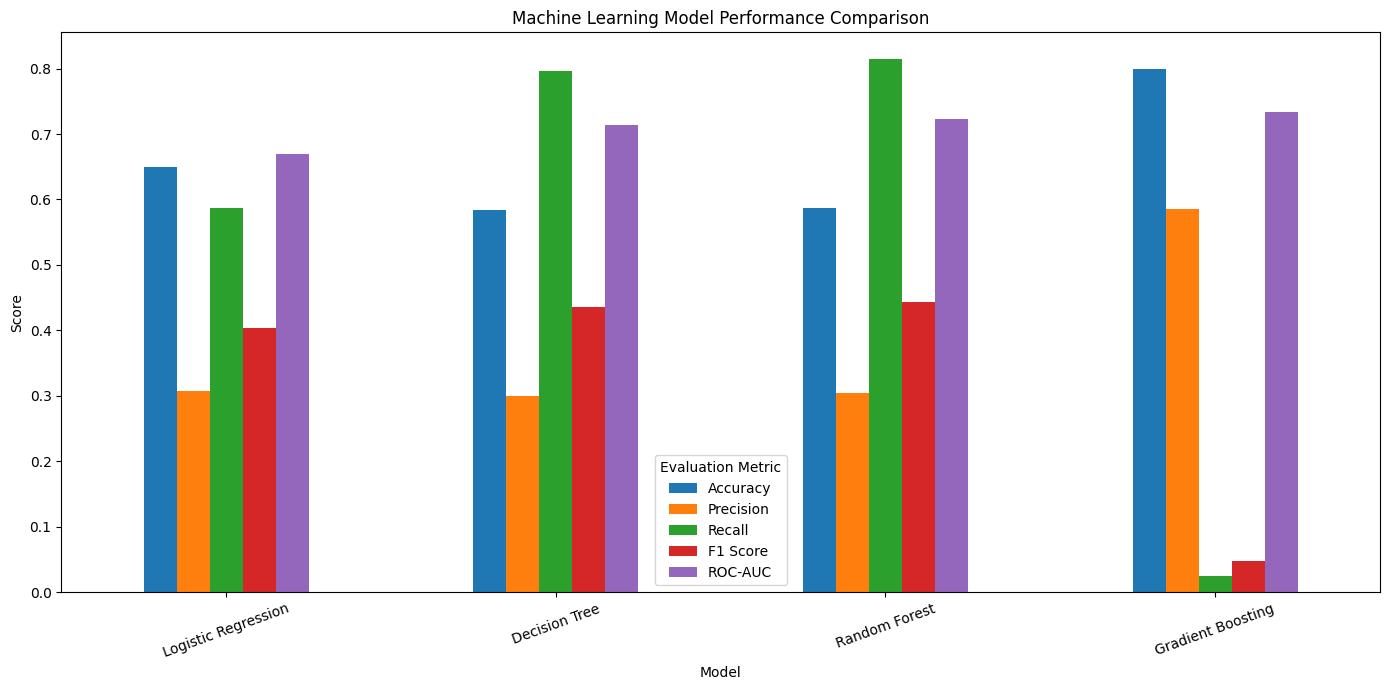

In [94]:
model_comparison_plot = model_comparison.set_index('Model')

model_comparison_plot.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Machine Learning Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(title='Evaluation Metric')
plt.tight_layout()

plt.show()

In [95]:
threshold_results = []

thresholds = np.arange(0.10, 0.51, 0.05)

for threshold in thresholds:

    threshold_predictions = (
        gradient_boosting_probabilities >= threshold
    ).astype(int)

    threshold_precision = precision_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': round(threshold_precision, 4),
        'Recall': round(threshold_recall, 4),
        'F1 Score': round(threshold_f1, 4)
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("===== THRESHOLD ANALYSIS =====")
display(threshold_results_df)

===== THRESHOLD ANALYSIS =====


,Threshold,Precision,Recall,F1 Score
0,0.10,0.2814,0.9404,0.4332
1,0.15,0.2865,0.9225,0.4372
2,0.20,0.3057,0.8308,0.4470
3,0.25,0.3357,0.6675,0.4468
4,0.30,0.3651,0.4775,0.4138
5,0.35,0.3999,0.2922,0.3376
6,0.40,0.4505,0.1571,0.2329
7,0.45,0.5045,0.0634,0.1127
8,0.50,0.5860,0.0244,0.0469


Confusion Matrix:
[[9221 8421]
 [ 755 3708]]


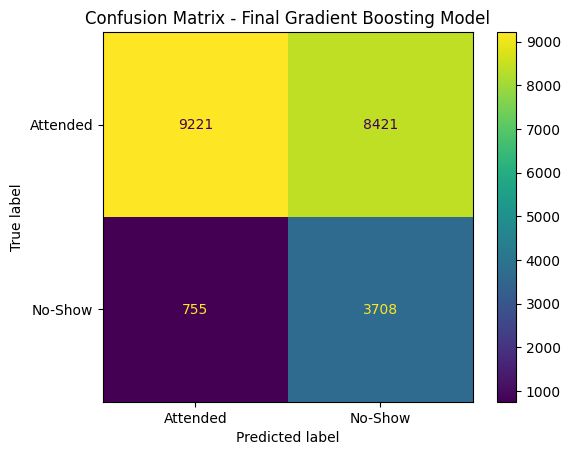

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_threshold = 0.20

final_predictions = (
    gradient_boosting_probabilities >= final_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    final_predictions
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Attended', 'No-Show']
)

disp.plot()

plt.title('Confusion Matrix - Final Gradient Boosting Model')

plt.show()

In [97]:
from sklearn.metrics import classification_report

final_classification_report = classification_report(
    y_test,
    final_predictions,
    target_names=['Attended', 'No-Show'],
    digits=4
)

print("===== FINAL MODEL CLASSIFICATION REPORT =====")
print(final_classification_report)

===== FINAL MODEL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Attended     0.9243    0.5227    0.6678     17642
     No-Show     0.3057    0.8308    0.4470      4463

    accuracy                         0.5849     22105
   macro avg     0.6150    0.6768    0.5574     22105
weighted avg     0.7994    0.5849    0.6232     22105



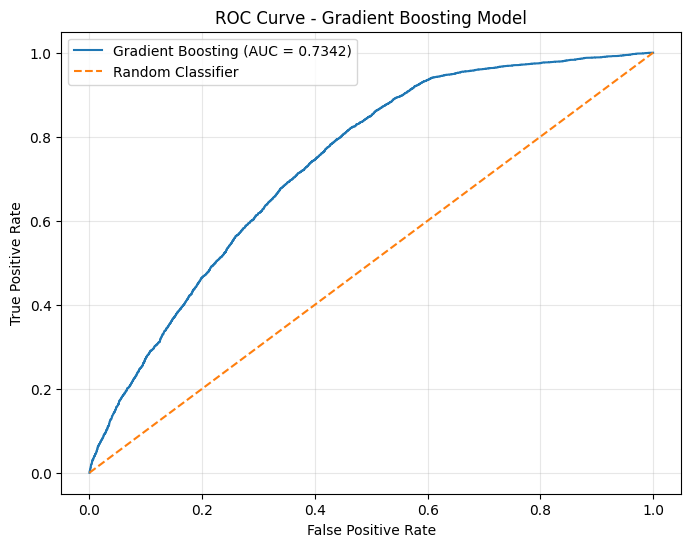

In [98]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    gradient_boosting_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Gradient Boosting (AUC = {gradient_boosting_roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve - Gradient Boosting Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

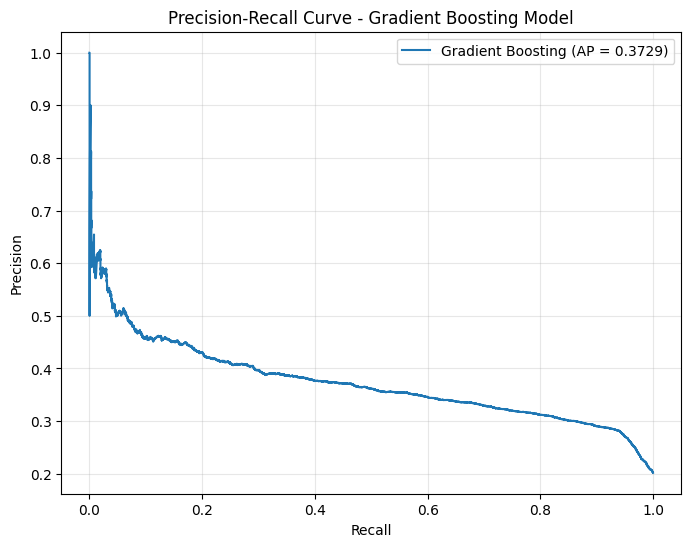

Average Precision Score: 0.3729


In [99]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    gradient_boosting_probabilities
)

average_precision = average_precision_score(
    y_test,
    gradient_boosting_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f'Gradient Boosting (AP = {average_precision:.4f})'
)

plt.title('Precision-Recall Curve - Gradient Boosting Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("Average Precision Score:", round(average_precision, 4))

In [100]:
encoded_feature_names = preprocessor.named_transformers_[
    'categorical'
].get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([
    encoded_feature_names,
    numerical_features
])

print("Total processed features:", len(all_feature_names))

Total processed features: 113


In [101]:
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': gradient_boosting_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)

print("Top 20 Most Important Features:")
display(feature_importance.head(20))

Top 20 Most Important Features:


,Feature,Importance
0,Waiting_Days,0.673618
1,Age,0.127268
2,Appointment_Day_Number,0.025338
3,SMS_received,0.020389
4,Scholarship,0.009105
5,Neighborhood_ITARARÉ,0.006765
6,Age_Group_Teenager,0.006279
7,Alcoholism,0.005565
8,Scheduled_Weekday_Tuesday,0.005259
9,Scheduled_Weekday_Friday,0.005244


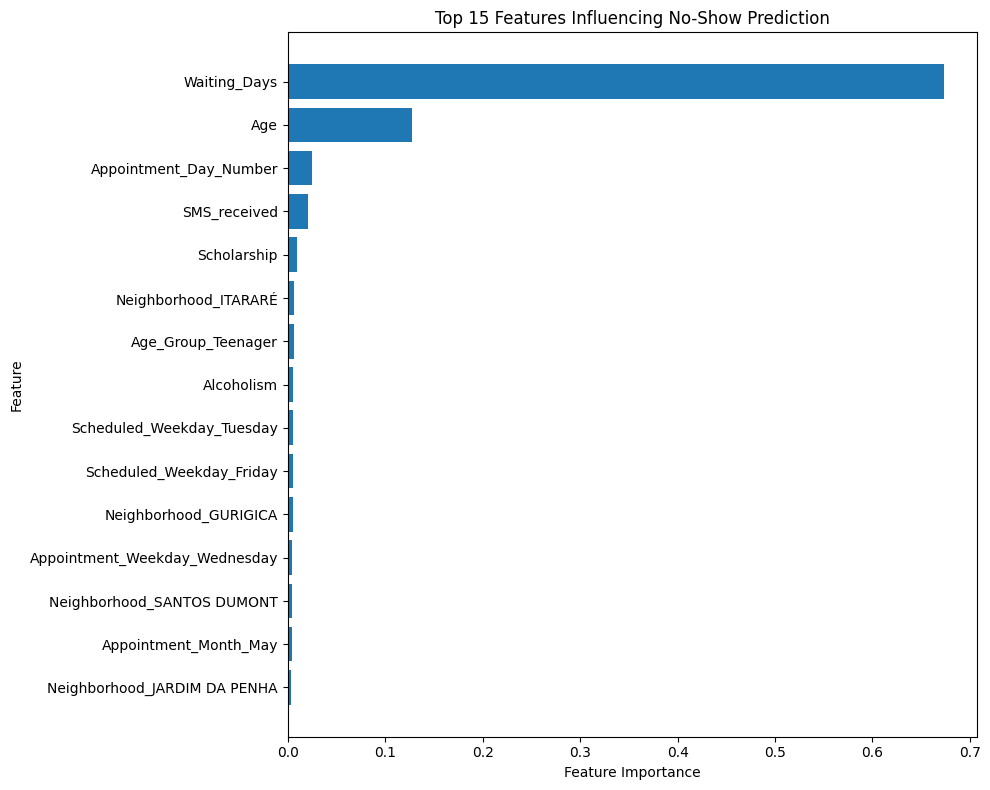

In [102]:
top_features = feature_importance.head(15).sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 15 Features Influencing No-Show Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [103]:
def get_feature_group(feature):
    if feature.startswith('Neighborhood_'):
        return 'Neighborhood'
    elif feature.startswith('Age_Group_'):
        return 'Age Group'
    elif feature.startswith('Appointment_Weekday_'):
        return 'Appointment Weekday'
    elif feature.startswith('Scheduled_Weekday_'):
        return 'Scheduled Weekday'
    elif feature.startswith('Appointment_Month_'):
        return 'Appointment Month'
    else:
        return feature

feature_importance['Feature_Group'] = (
    feature_importance['Feature']
    .apply(get_feature_group)
)

grouped_importance = (
    feature_importance
    .groupby('Feature_Group')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("===== GROUPED FEATURE IMPORTANCE =====")
display(grouped_importance)

===== GROUPED FEATURE IMPORTANCE =====


,Feature_Group,Importance
0,Waiting_Days,0.673618
1,Age,0.127268
2,Neighborhood,0.070281
3,Appointment_Day_Number,0.025338
4,SMS_received,0.020389
5,Scheduled Weekday,0.018963
6,Appointment Weekday,0.016856
7,Age Group,0.013766
8,Scholarship,0.009105
9,Appointment Month,0.005753


In [104]:
final_model_summary = pd.DataFrame({
    'Metric': [
        'Model',
        'Decision Threshold',
        'Accuracy',
        'Precision (No-Show)',
        'Recall (No-Show)',
        'F1 Score (No-Show)',
        'ROC-AUC',
        'Average Precision'
    ],
    'Value': [
        'Gradient Boosting',
        0.20,
        round(accuracy_score(y_test, final_predictions), 4),
        round(precision_score(y_test, final_predictions), 4),
        round(recall_score(y_test, final_predictions), 4),
        round(f1_score(y_test, final_predictions), 4),
        round(gradient_boosting_roc_auc, 4),
        round(average_precision, 4)
    ]
})

print("===== FINAL MODEL SUMMARY =====")
display(final_model_summary)

===== FINAL MODEL SUMMARY =====


,Metric,Value
0,Model,Gradient Boosting
1,Decision Threshold,0.2
2,Accuracy,0.5849
3,Precision (No-Show),0.3057
4,Recall (No-Show),0.8308
5,F1 Score (No-Show),0.447
6,ROC-AUC,0.7342
7,Average Precision,0.3729


In [105]:
def predict_no_show_risk(
    gender,
    age,
    neighborhood,
    scholarship,
    hypertension,
    diabetes,
    alcoholism,
    handicap,
    sms_received,
    waiting_days,
    appointment_weekday,
    scheduled_weekday,
    appointment_month,
    appointment_day_number,
    age_group
):

    patient_data = pd.DataFrame({
        'Gender': [gender],
        'Age': [age],
        'Neighborhood': [neighborhood],
        'Scholarship': [scholarship],
        'Hypertension': [hypertension],
        'Diabetes': [diabetes],
        'Alcoholism': [alcoholism],
        'Handicap': [handicap],
        'SMS_received': [sms_received],
        'Waiting_Days': [waiting_days],
        'Appointment_Weekday': [appointment_weekday],
        'Scheduled_Weekday': [scheduled_weekday],
        'Appointment_Month': [appointment_month],
        'Appointment_Day_Number': [appointment_day_number],
        'Age_Group': [age_group]
    })

    patient_processed = preprocessor.transform(
        patient_data
    )

    no_show_probability = gradient_boosting_model.predict_proba(
        patient_processed
    )[0, 1]

    if no_show_probability >= 0.50:
        risk_level = "HIGH"
        recommendation = (
            "Send reminder and consider follow-up call."
        )

    elif no_show_probability >= 0.20:
        risk_level = "MEDIUM"
        recommendation = (
            "Send an additional appointment reminder."
        )

    else:
        risk_level = "LOW"
        recommendation = (
            "Standard appointment reminder is sufficient."
        )

    print("===== PATIENT NO-SHOW RISK PREDICTION =====")
    print("No-Show Probability:",
          round(no_show_probability * 100, 2), "%")
    print("Risk Level:", risk_level)
    print("Recommended Action:", recommendation)

    return {
        'No_Show_Probability': no_show_probability,
        'Risk_Level': risk_level,
        'Recommendation': recommendation
    }

In [106]:
sample_prediction = predict_no_show_risk(
    gender='F',
    age=25,
    neighborhood='ITARARÉ',
    scholarship=0,
    hypertension=0,
    diabetes=0,
    alcoholism=0,
    handicap=0,
    sms_received=0,
    waiting_days=30,
    appointment_weekday='Wednesday',
    scheduled_weekday='Monday',
    appointment_month='May',
    appointment_day_number=15,
    age_group='Young Adult'
)

===== PATIENT NO-SHOW RISK PREDICTION =====
No-Show Probability: 55.41 %
Risk Level: HIGH
Recommended Action: Send reminder and consider follow-up call.


In [107]:
test_no_show_probabilities = gradient_boosting_model.predict_proba(
    X_test_processed
)[:, 1]

test_risk_levels = np.select(
    [
        test_no_show_probabilities >= 0.50,
        test_no_show_probabilities >= 0.20
    ],
    [
        'HIGH',
        'MEDIUM'
    ],
    default='LOW'
)

risk_predictions = pd.DataFrame({
    'Actual_No_Show': y_test.values,
    'No_Show_Probability': test_no_show_probabilities,
    'Risk_Level': test_risk_levels
})

print("===== SAMPLE RISK PREDICTIONS =====")
display(risk_predictions.head(10))

===== SAMPLE RISK PREDICTIONS =====


,Actual_No_Show,No_Show_Probability,Risk_Level
0,1,0.258672,MEDIUM
1,0,0.194268,LOW
2,0,0.290116,MEDIUM
3,0,0.201310,MEDIUM
4,0,0.038610,LOW
5,0,0.025999,LOW
6,0,0.378901,MEDIUM
7,1,0.358265,MEDIUM
8,0,0.059391,LOW
9,0,0.375130,MEDIUM


In [108]:
risk_distribution = (
    risk_predictions['Risk_Level']
    .value_counts()
    .reindex(['LOW', 'MEDIUM', 'HIGH'])
    .fillna(0)
    .astype(int)
)

print("===== RISK LEVEL DISTRIBUTION =====")
print(risk_distribution)

print("\nRisk Level Percentage:")
print(
    (risk_distribution / len(risk_predictions) * 100)
    .round(2)
)

===== RISK LEVEL DISTRIBUTION =====
Risk_Level
LOW        9976
MEDIUM    11943
HIGH        186
Name: count, dtype: int64

Risk Level Percentage:
Risk_Level
LOW       45.13
MEDIUM    54.03
HIGH       0.84
Name: count, dtype: float64


In [109]:
risk_performance = (
    risk_predictions
    .groupby('Risk_Level')
    .agg(
        Appointment_Count=('Actual_No_Show', 'count'),
        Actual_No_Show_Rate=('Actual_No_Show', 'mean')
    )
    .reindex(['LOW', 'MEDIUM', 'HIGH'])
)

risk_performance['Actual_No_Show_Rate'] = (
    risk_performance['Actual_No_Show_Rate'] * 100
).round(2)

print("===== RISK LEVEL PERFORMANCE =====")
display(risk_performance)

===== RISK LEVEL PERFORMANCE =====


,Appointment_Count,Actual_No_Show_Rate
Risk_Level,,
LOW,9976,7.57
MEDIUM,11943,30.13
HIGH,186,58.60


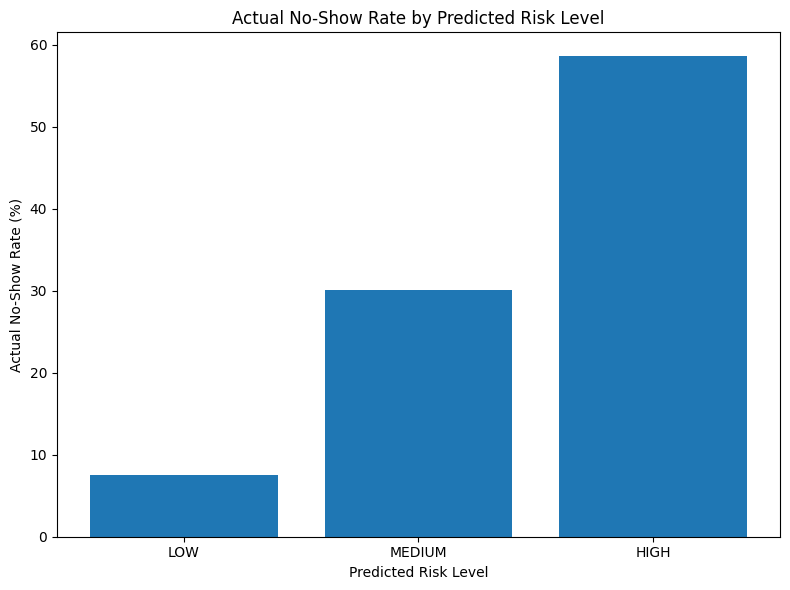

In [110]:
plt.figure(figsize=(8, 6))

plt.bar(
    risk_performance.index,
    risk_performance['Actual_No_Show_Rate']
)

plt.title('Actual No-Show Rate by Predicted Risk Level')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual No-Show Rate (%)')

plt.tight_layout()
plt.show()

In [111]:
final_risk_summary = risk_performance.copy()

final_risk_summary['Risk_Percentage'] = (
    final_risk_summary['Appointment_Count']
    / final_risk_summary['Appointment_Count'].sum()
    * 100
).round(2)

final_risk_summary = final_risk_summary[
    [
        'Appointment_Count',
        'Risk_Percentage',
        'Actual_No_Show_Rate'
    ]
]

print("===== FINAL RISK SUMMARY =====")
display(final_risk_summary)

===== FINAL RISK SUMMARY =====


,Appointment_Count,Risk_Percentage,Actual_No_Show_Rate
Risk_Level,,,
LOW,9976,45.13,7.57
MEDIUM,11943,54.03,30.13
HIGH,186,0.84,58.60


In [112]:
waiting_time_summary = (
    data.groupby('Waiting_Time_Group')
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

waiting_time_summary['No_Show_Rate'] = (
    waiting_time_summary['No_Show_Rate'] * 100
).round(2)

waiting_order = [
    'Same Day',
    '1 Week',
    '1 Month',
    '1-3 Months',
    '3+ Months'
]

waiting_time_summary = (
    waiting_time_summary
    .reindex(waiting_order)
)

print("===== WAITING TIME RISK SUMMARY =====")
display(waiting_time_summary)

===== WAITING TIME RISK SUMMARY =====


,Appointment_Count,No_Show_Rate
Waiting_Time_Group,,
Same Day,38562,4.65
1 Week,32185,24.15
1 Month,29396,31.72
1-3 Months,10161,33.16
3+ Months,217,25.81


In [113]:
sms_summary = (
    data.groupby('SMS_received')
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

sms_summary['No_Show_Rate'] = (
    sms_summary['No_Show_Rate'] * 100
).round(2)

sms_summary.index = [
    'No SMS',
    'SMS Received'
]

print("===== OVERALL SMS EFFECTIVENESS =====")
display(sms_summary)

===== OVERALL SMS EFFECTIVENESS =====


,Appointment_Count,No_Show_Rate
No SMS,75039,16.70
SMS Received,35482,27.57


In [114]:
sms_waiting_summary = (
    data.groupby(
        ['Waiting_Time_Group', 'SMS_received']
    )
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

sms_waiting_summary['No_Show_Rate'] = (
    sms_waiting_summary['No_Show_Rate'] * 100
).round(2)

sms_waiting_summary = sms_waiting_summary.reset_index()

sms_waiting_summary['SMS_Status'] = (
    sms_waiting_summary['SMS_received']
    .map({
        0: 'No SMS',
        1: 'SMS Received'
    })
)

print("===== SMS EFFECTIVENESS BY WAITING TIME =====")
display(
    sms_waiting_summary[
        [
            'Waiting_Time_Group',
            'SMS_Status',
            'Appointment_Count',
            'No_Show_Rate'
        ]
    ]
)

===== SMS EFFECTIVENESS BY WAITING TIME =====


,Waiting_Time_Group,SMS_Status,Appointment_Count,No_Show_Rate
0,1 Month,No SMS,11872,35.55
1,1 Month,SMS Received,17524,29.13
2,1 Week,No SMS,20637,24.36
3,1 Week,SMS Received,11548,23.76
4,1-3 Months,No SMS,3890,37.79
5,1-3 Months,SMS Received,6271,30.28
6,3+ Months,No SMS,78,24.36
7,3+ Months,SMS Received,139,26.62
8,Same Day,No SMS,38562,4.65


In [115]:
age_group_summary = (
    data.groupby('Age_Group')
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

age_group_summary['No_Show_Rate'] = (
    age_group_summary['No_Show_Rate'] * 100
).round(2)

age_group_summary = age_group_summary.sort_values(
    'No_Show_Rate',
    ascending=False
)

print("===== AGE GROUP RISK ANALYSIS =====")
display(age_group_summary)

===== AGE GROUP RISK ANALYSIS =====


,Appointment_Count,No_Show_Rate
Age_Group,,
Teenager,9374,25.95
Young Adult,28868,23.13
Child,21035,20.47
Middle-Aged Adult,30072,18.81
Elderly,3362,16.33
Senior,17810,15.12


In [116]:
health_conditions = {
    'Hypertension': 'Hypertension',
    'Diabetes': 'Diabetes',
    'Alcoholism': 'Alcoholism',
    'Handicap': 'Handicap'
}

health_condition_results = []

for condition_name, column_name in health_conditions.items():

    without_condition = data[
        data[column_name] == 0
    ]['No_Show_Flag'].mean() * 100

    with_condition = data[
        data[column_name] == 1
    ]['No_Show_Flag'].mean() * 100

    health_condition_results.append({
        'Health_Condition': condition_name,
        'Without_Condition_No_Show_Rate': round(
            without_condition, 2
        ),
        'With_Condition_No_Show_Rate': round(
            with_condition, 2
        )
    })

health_condition_summary = pd.DataFrame(
    health_condition_results
)

print("===== HEALTH CONDITION RISK ANALYSIS =====")
display(health_condition_summary)

===== HEALTH CONDITION RISK ANALYSIS =====


,Health_Condition,Without_Condition_No_Show_Rate,With_Condition_No_Show_Rate
0,Hypertension,20.90,17.30
1,Diabetes,20.36,18.00
2,Alcoholism,20.19,20.15
3,Handicap,20.23,17.84


In [117]:
neighborhood_summary = (
    data.groupby('Neighborhood')
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

neighborhood_summary['No_Show_Rate'] = (
    neighborhood_summary['No_Show_Rate'] * 100
).round(2)

neighborhood_summary = neighborhood_summary[
    neighborhood_summary['Appointment_Count'] >= 500
]

neighborhood_summary = neighborhood_summary.sort_values(
    'No_Show_Rate',
    ascending=False
)

print("===== TOP 10 HIGH-RISK NEIGHBORHOODS =====")
display(
    neighborhood_summary.head(10)
)

===== TOP 10 HIGH-RISK NEIGHBORHOODS =====


,Appointment_Count,No_Show_Rate
Neighborhood,,
SANTOS DUMONT,1276,28.92
SANTA CLARA,506,26.48
ITARARÉ,3514,26.27
JESUS DE NAZARETH,2853,24.40
ILHA DO PRÍNCIPE,2266,23.48
CARATOÍRA,2565,23.04
ANDORINHAS,2262,23.03
PRAIA DO SUÁ,1288,22.83
GURIGICA,2018,22.60


In [118]:
weekday_summary = (
    data.groupby('Appointment_Weekday')
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

weekday_summary['No_Show_Rate'] = (
    weekday_summary['No_Show_Rate'] * 100
).round(2)

weekday_summary = weekday_summary.sort_values(
    'No_Show_Rate',
    ascending=False
)

month_summary = (
    data.groupby('Appointment_Month')
    .agg(
        Appointment_Count=('No_Show_Flag', 'count'),
        No_Show_Rate=('No_Show_Flag', 'mean')
    )
)

month_summary['No_Show_Rate'] = (
    month_summary['No_Show_Rate'] * 100
).round(2)

month_summary = month_summary.sort_values(
    'No_Show_Rate',
    ascending=False
)

print("===== APPOINTMENT WEEKDAY RISK =====")
display(weekday_summary)

print("\n===== APPOINTMENT MONTH RISK =====")
display(month_summary)

===== APPOINTMENT WEEKDAY RISK =====


,Appointment_Count,No_Show_Rate
Appointment_Weekday,,
Saturday,39,23.08
Friday,19019,21.23
Monday,22713,20.64
Tuesday,25638,20.09
Wednesday,25866,19.69
Thursday,17246,19.35



===== APPOINTMENT MONTH RISK =====


,Appointment_Count,No_Show_Rate
Appointment_Month,,
May,80836,20.78
April,3235,19.57
June,26450,18.46


In [119]:
business_insights = pd.DataFrame({
    'Insight_Area': [
        'Waiting Time',
        'Age Group',
        'SMS Reminder',
        'Neighborhood',
        'Appointment Weekday',
        'Health Conditions',
        'Risk Prediction'
    ],
    'Key_Finding': [
        'Waiting 1-3 months shows the highest no-show risk.',
        'Teenagers have the highest no-show rate among age groups.',
        'SMS appears most helpful for longer waiting periods.',
        'Santos Dumont has the highest no-show rate among high-volume neighborhoods.',
        'Friday has a relatively high no-show rate with substantial appointment volume.',
        'Health conditions show limited influence on no-show behavior.',
        'High-risk predictions correspond to substantially higher actual no-show rates.'
    ]
})

print("===== FINAL BUSINESS INSIGHTS =====")
display(business_insights)

===== FINAL BUSINESS INSIGHTS =====


,Insight_Area,Key_Finding
0,Waiting Time,Waiting 1-3 months shows the highest no-show r...
1,Age Group,Teenagers have the highest no-show rate among ...
2,SMS Reminder,SMS appears most helpful for longer waiting pe...
3,Neighborhood,Santos Dumont has the highest no-show rate amo...
4,Appointment Weekday,Friday has a relatively high no-show rate with...
5,Health Conditions,Health conditions show limited influence on no...
6,Risk Prediction,High-risk predictions correspond to substantia...


In [120]:
recommendations = pd.DataFrame({
    'Priority': [
        'High',
        'High',
        'High',
        'Medium',
        'Medium',
        'Low'
    ],
    'Recommendation': [
        'Prioritize appointments with long waiting periods for additional reminders.',
        'Use the ML risk model to identify high-risk appointments for proactive follow-up.',
        'Target teenagers and young adults with stronger reminder strategies.',
        'Focus outreach efforts on high-risk neighborhoods with sufficient appointment volume.',
        'Provide additional reminders for appointments scheduled toward higher-risk weekdays.',
        'Do not rely on health conditions alone when determining no-show risk.'
    ],
    'Expected_Impact': [
        'Reduce no-shows caused by long gaps between scheduling and appointments.',
        'Allow staff to focus resources on patients most likely to miss appointments.',
        'Improve attendance among younger patient groups.',
        'Enable geographically targeted engagement strategies.',
        'Improve attendance through better appointment communication.',
        'Avoid ineffective targeting based solely on medical conditions.'
    ]
})

print("===== FINAL ACTIONABLE RECOMMENDATIONS =====")
display(recommendations)

===== FINAL ACTIONABLE RECOMMENDATIONS =====


,Priority,Recommendation,Expected_Impact
0,High,Prioritize appointments with long waiting peri...,Reduce no-shows caused by long gaps between sc...
1,High,Use the ML risk model to identify high-risk ap...,Allow staff to focus resources on patients mos...
2,High,Target teenagers and young adults with stronge...,Improve attendance among younger patient groups.
3,Medium,Focus outreach efforts on high-risk neighborho...,Enable geographically targeted engagement stra...
4,Medium,Provide additional reminders for appointments ...,Improve attendance through better appointment ...
5,Low,Do not rely on health conditions alone when de...,Avoid ineffective targeting based solely on me...


In [121]:
powerbi_data = data.copy()

powerbi_data.to_csv(
    'patient_no_show_powerbi_data.csv',
    index=False
)

print("Power BI dataset exported successfully!")
print("Rows:", powerbi_data.shape[0])
print("Columns:", powerbi_data.shape[1])

Power BI dataset exported successfully!
Rows: 110521
Columns: 26
